Region
North    10400.000000
East      4800.000000
West      3172.727273
South     1700.000000
Name: Sales, dtype: float64


/tmp/ipykernel_64202/348304265.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sales_df['Sales'].fillna(sales_df['Sales'].mean(numeric_only=True), inplace=True)


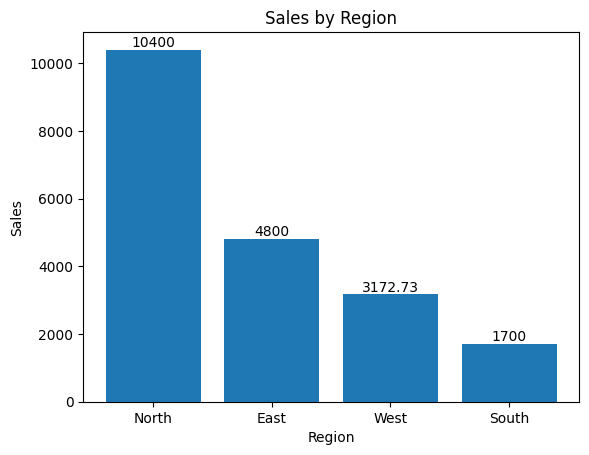

<function matplotlib.pyplot.show(close=None, block=None)>

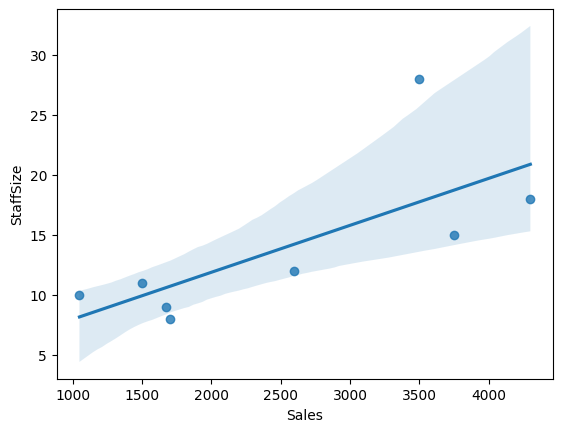

In [1]:
import pandas as pd
import io
from matplotlib import pyplot as plt
import seaborn

sales_csv = """Date,Store,Region,Sales,ItemsSold
2025-01-05,A1,North,1250,80
2025-01-05,B2,South,800,55
2025-01-05,C3,North,2100,120
2025-01-12,A1,North,1350,85
2025-01-12,D4,West,,60
2025-01-12,E5,East,1850,110
2025-01-19,F6,West,1500,95
2025-01-19,G7,North,3500,200
2025-01-19,H8,East,1050,70
2025-01-26,B2,South,900,65
2025-01-26,C3,North,2200,130
2025-01-26,E5,East,1900,115
"""

stores_csv = """Store,Type,StaffSize,SquareFootage
A1,Urban,12,1500
B2,Suburban,8,1200
C3,Urban,18,2500
D4,Rural,9,1300
E5,Suburban,15,2000
F6,Rural,11,1400
G7,Urban,28,3500
H8,Suburban,10,1800
"""

# Load and clean sales data
sales_df = pd.read_csv(io.StringIO(sales_csv), parse_dates=['Date'])
sales_df['Sales'].fillna(sales_df['Sales'].mean(numeric_only=True), inplace=True)

# Load stores data
stores_df = pd.read_csv(io.StringIO(stores_csv))

# Merge the dataframes
merged_df = pd.merge(sales_df, stores_df, on='Store')

sales_by_region = merged_df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(sales_by_region)

fig, ax = plt.subplots()
bars = ax.bar(sales_by_region.keys(), sales_by_region)
ax.bar_label(bars)
ax.set_xlabel('Region')
ax.set_ylabel('Sales')
ax.set_title('Sales by Region')
plt.show()

sales_and_staff = merged_df.groupby('StaffSize')['Sales'].sum().sort_values(ascending=False)
seaborn.regplot(x=sales_and_staff, y=sales_and_staff.keys())
plt.show